# Amazon Reviews 2023 — Electronics EDA

Perform exploratory data analysis (EDA) on the Amazon reviews dataset (Lesson 8):

- Distribution of ratings
- Correlation between ratings and price
- Popular items / categories by review count

Dataset: https://amazon-reviews-2023.github.io/ — files in `data/raw/`:
`Electronics.jsonl.gz` (~6 GB, reviews) and `meta_Electronics.jsonl.gz` (~1.2 GB, item metadata), joined on `parent_asin`.

**Approach:** the review file is far too large to load into pandas, so we use **DuckDB** to scan the gzipped JSONL out-of-core. We first do a one-off **ETL pass** projecting only the columns we need into compact Parquet under `data/processed/`; every analysis below then runs fast on Parquet.

In [3]:
import os, time
from pathlib import Path
import duckdb
import gzip
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("../../").resolve()          # notebook lives in notebooks/week1/
RAW  = ROOT / "data" / "raw"
PROC = ROOT / "data" / "processed"
(PROC / "_tmp").mkdir(parents=True, exist_ok=True)

REVIEWS_GZ = RAW / "Electronics.jsonl.gz"
META_GZ    = RAW / "meta_Electronics.jsonl.gz"
REVIEWS_PQ = PROC / "reviews.parquet"
META_PQ    = PROC / "meta.parquet"

con = duckdb.connect()
con.execute(f"SET memory_limit='6GB'; SET threads={os.cpu_count()}; "
            f"SET temp_directory='{PROC / '_tmp'}';")

## check file

In [5]:
with gzip.open(REVIEWS_GZ, "rt") as f:
    first_line = json.loads(f.readline())

display(first_line)

{'rating': 3.0,
 'title': 'Smells like gasoline! Going back!',
 'text': 'First & most offensive: they reek of gasoline so if you are sensitive/allergic to petroleum products like I am you will want to pass on these.  Second: the phone adapter is useless as-is. Mine was not drilled far enough to be able to tighten it into place for my iPhone 12 max. It just slipped & slid all over. Stupid me putting the adapter together first without picking up the binoculars to smell them bc I wasted 15 minutes trying to figure out how to put the adapter together bc it does not come with instructions!  I had to come back here to the website which was a total pain. Third: the tripod is also useless. I would not trust the iOS to hold my $1600 phone nor even a Mattel Barbie for that matter. It’s just inefficient for the job imo.  Third: in order to try to give an honest review I did don gloves & eyewear to check the binoculars out.  They seemed average except for mine seemed to be missing about 10% of the

In [6]:
with gzip.open(META_GZ, "rt") as f:
    first_line = json.loads(f.readline())

display(first_line)

{'main_category': 'All Electronics',
 'title': 'FS-1051 FATSHARK TELEPORTER V3 HEADSET',
 'average_rating': 3.5,
 'rating_number': 6,
 'features': [],
 'description': ['Teleporter V3 The “Teleporter V3” kit sets a new level of value in the FPV world with Fat Shark renowned performance and quality. The fun of FPV is experienced firsthand through the large screen FPV headset with integrated NexwaveRF receiver technology while simultaneously recording onboard HD footage with the included “PilotHD” camera. The “Teleporter V3” kit comes complete with everything you need to step into the cockpit of your FPV vehicle. We’ve included our powerful 250mW 5.8Ghz transmitter, 25 degree FOV headset (largest QVGA display available), the brand new “PilotHD” camera with live AV out and all the cables, antennas and connectors needed.'],
 'price': None,
 'images': [{'thumb': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_US40_.jpg',
   'large': 'https://m.media-amazon.com/images/I/41qrX56lsYL._AC_.

## filter out only recent items
only care items appear in store >= 2022

In [9]:
def filter_data_by_date(data: dict) -> bool:
    filter = False
    if int(data['details']['Date First Available'][-4:]) >= 2022:
        filter = True
    return filter

In [11]:
with gzip.open("../../data/raw/meta_Electronics.jsonl.gz", "rt") as fp:
    with open("../../data/raw/meta_Electronics_2022_2023.jsonl", "a", encoding="utf-8") as fp_out:
        with open("../../data/raw/meta_Electronics_2022_2023_no_date.jsonl", "a", encoding="utf-8") as fp_out_no_date:
            i = 0
            for line in fp:
                data = json.loads(line.strip())
                try:
                    filter = filter_data_by_date(data)
                    if not filter:
                        json.dump(data, fp_out)
                        fp_out.write("\n")
                        fp_out.flush()
                except:
                    json.dump(data, fp_out_no_date)
                    fp_out_no_date.write("\n")
                    fp_out_no_date.flush()

                i += 1
                if i % 10000 == 0:
                    print(f"Processed {i} lines")

Processed 10000 lines
Processed 20000 lines
Processed 30000 lines
Processed 40000 lines
Processed 50000 lines
Processed 60000 lines
Processed 70000 lines
Processed 80000 lines
Processed 90000 lines
Processed 100000 lines
Processed 110000 lines
Processed 120000 lines
Processed 130000 lines
Processed 140000 lines
Processed 150000 lines
Processed 160000 lines
Processed 170000 lines
Processed 180000 lines
Processed 190000 lines
Processed 200000 lines
Processed 210000 lines
Processed 220000 lines
Processed 230000 lines
Processed 240000 lines
Processed 250000 lines
Processed 260000 lines
Processed 270000 lines
Processed 280000 lines
Processed 290000 lines
Processed 300000 lines
Processed 310000 lines
Processed 320000 lines
Processed 330000 lines
Processed 340000 lines
Processed 350000 lines
Processed 360000 lines
Processed 370000 lines
Processed 380000 lines
Processed 390000 lines
Processed 400000 lines
Processed 410000 lines
Processed 420000 lines
Processed 430000 lines
Processed 440000 lin

## Explore distribution by categories

In [13]:
df = pd.read_json('/Users/hang/Documents/Development/ai-eng-course/ai-eng-project/data/raw/meta_Electronics_2022_2023.jsonl', lines=True)
df.head()

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,subtitle,author
0,All Electronics,FS-1051 FATSHARK TELEPORTER V3 HEADSET,3.5,6,[],[Teleporter V3 The “Teleporter V3” kit sets a ...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],Fat Shark,"[Electronics, Television & Video, Video Glasses]","{'Date First Available': 'August 2, 2014', 'Ma...",B00MCW7G9M,NaN,NaN,NaN
1,All Electronics,Ce-H22B12-S1 4Kx2K Hdmi 4Port,5.0,1,"[UPC: 662774021904, Weight: 0.600 lbs]",[HDMI In - HDMI Out],NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],SIIG,"[Electronics, Television & Video, Accessories,...",{'Product Dimensions': '0.83 x 4.17 x 2.05 inc...,B00YT6XQSE,NaN,NaN,NaN
2,Computers,Digi-Tatoo Decal Skin Compatible With MacBook ...,4.5,246,[WARNING: Please IDENTIFY MODEL NUMBER on the ...,[],19.99,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'AL 2Sides Video', 'url': 'https://...",Digi-Tatoo,"[Electronics, Computers & Accessories, Laptop ...","{'Brand': 'Digi-Tatoo', 'Color': 'Fresh Marble...",B07SM135LS,NaN,NaN,NaN
3,AMAZON FASHION,NotoCity Compatible with Vivoactive 4 band 22m...,4.5,233,[☛NotoCity 22mm band is designed for Vivoactiv...,[],9.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],NotoCity,"[Electronics, Wearable Technology, Clips, Arm ...","{'Date First Available': 'May 29, 2020', 'Manu...",B089CNGZCW,NaN,NaN,NaN
4,Cell Phones & Accessories,Motorola Droid X Essentials Combo Pack,3.8,64,"[New Droid X Essentials Combo Pack, Exclusive ...",[all Genuine High Quality Motorola Made Access...,14.99,[{'thumb': 'https://m.media-amazon.com/images/...,[],Verizon,"[Electronics, Computers & Accessories, Compute...",{'Product Dimensions': '11.6 x 6.9 x 3.1 inche...,B004E2Z88O,NaN,NaN,NaN


<Axes: xlabel='main_category'>

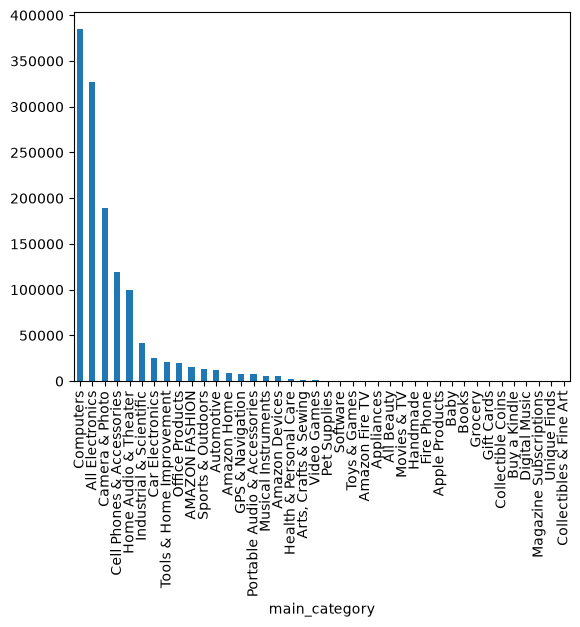

In [14]:
df['main_category'].value_counts().plot(kind='bar')

In [21]:
df_ratings_100 = df[df['rating_number'] >= 100].copy()

In [23]:
len(df_ratings_100), len(df)

(227335, 1393859)

## explore distribution of ratings

<Axes: ylabel='Frequency'>

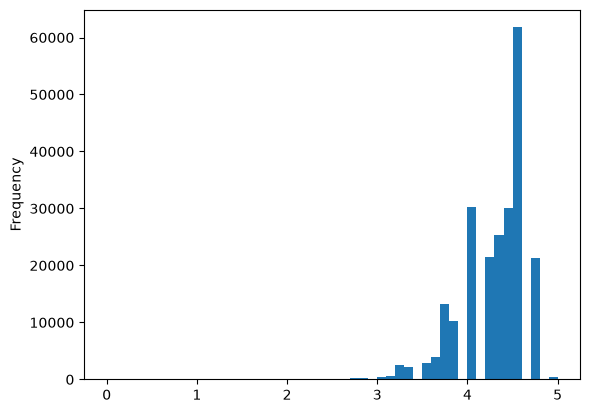

In [28]:
df_ratings_100['average_rating'].plot(kind='hist', bins=50, range=(0,5))

<Axes: ylabel='Frequency'>

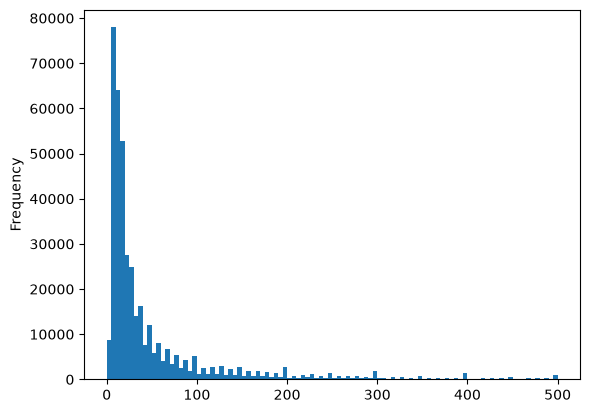

In [32]:
df['price'].plot(kind='hist', bins=100, range=(0,500))

## sample 1000

<Axes: ylabel='Frequency'>

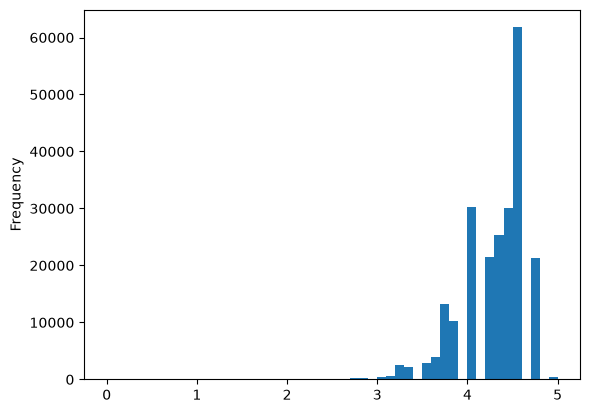

In [29]:
df_sample_1000 = df_ratings_100.sample(1000, random_state=42)
df_ratings_100['average_rating'].plot(kind='hist', bins=50, range=(0,5))

<Axes: ylabel='Frequency'>

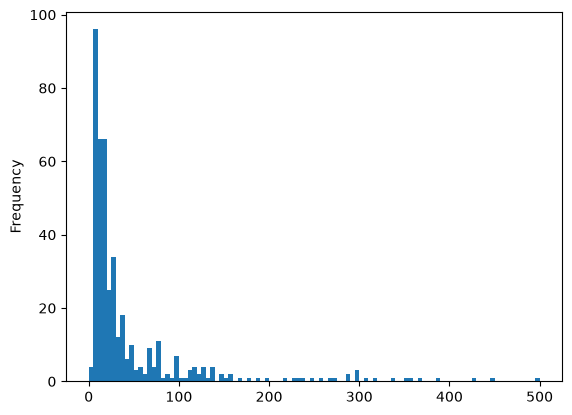

In [31]:
df_sample_1000['price'].plot(kind='hist', bins=100, range=(0,500))

<Axes: xlabel='main_category'>

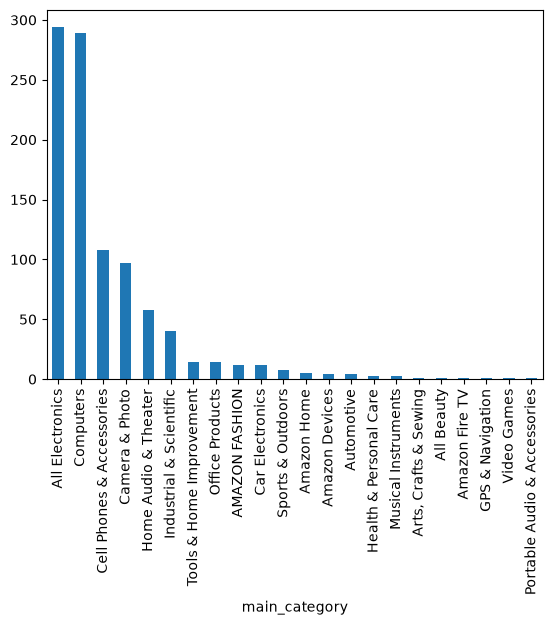

In [33]:
df_sample_1000['main_category'].value_counts().plot(kind='bar')

In [ ]:
df_ratings_100.to_json('../../data/raw/meta_Electronics_2022_2023_ratings_100.jsonl', orient='records', lines=True)
df_sample_1000.to_json('../../data/raw/meta_Electronics_2022_2023_ratings_100_sample_1000.jsonl', orient='records', lines=True)

## extract ratings from saved sample data

In [37]:
df_ratings_100 = pd.read_json('../../data/raw/meta_Electronics_2022_2023_ratings_100.jsonl', lines=True)
df_sample_1000 = pd.read_json('../../data/raw/meta_Electronics_2022_2023_ratings_100_sample_1000.jsonl', lines=True)

In [43]:
with gzip.open("../../data/raw/Electronics.jsonl.gz", "r") as fp:
    with open("../../data/raw/Electronics_2022_2023_with_category_ratings_100_sample_1000.jsonl", "a") as fp_out:
        id_list = set(df_sample_1000["parent_asin"].values)
        i = 0
        for line in fp:
            data = json.loads(line.strip())
            if data["parent_asin"] in id_list:
                json.dump(data, fp_out)
                fp_out.write("\n")
                fp_out.flush()

            i += 1
            if i % 100000 == 0:
                print(f"Processed {i} lines")

Processed 100000 lines
Processed 200000 lines
Processed 300000 lines
Processed 400000 lines
Processed 500000 lines
Processed 600000 lines
Processed 700000 lines
Processed 800000 lines
Processed 900000 lines
Processed 1000000 lines
Processed 1100000 lines
Processed 1200000 lines
Processed 1300000 lines
Processed 1400000 lines
Processed 1500000 lines
Processed 1600000 lines
Processed 1700000 lines
Processed 1800000 lines
Processed 1900000 lines
Processed 2000000 lines
Processed 2100000 lines
Processed 2200000 lines
Processed 2300000 lines
Processed 2400000 lines
Processed 2500000 lines
Processed 2600000 lines
Processed 2700000 lines
Processed 2800000 lines
Processed 2900000 lines
Processed 3000000 lines
Processed 3100000 lines
Processed 3200000 lines
Processed 3300000 lines
Processed 3400000 lines
Processed 3500000 lines
Processed 3600000 lines
Processed 3700000 lines
Processed 3800000 lines
Processed 3900000 lines
Processed 4000000 lines
Processed 4100000 lines
Processed 4200000 lines
P

# personal

## gzipped JSONL → compact Parquet
Scans each `.gz` once (reviews ~30s, meta ~10s). Idempotent — skips if the Parquet already exists.

In [ ]:
def etl():
    if not REVIEWS_PQ.exists():
        t = time.time()
        con.execute(f"""
          COPY (
            SELECT rating, parent_asin
            FROM read_json('{REVIEWS_GZ}',
                 columns={{'rating':'DOUBLE','parent_asin':'VARCHAR'}}, ignore_errors=true)
            WHERE parent_asin IS NOT NULL
          ) TO '{REVIEWS_PQ}' (FORMAT parquet);""")
        print(f"wrote reviews.parquet in {time.time()-t:.0f}s")
    if not META_PQ.exists():
        t = time.time()
        con.execute(f"""
          COPY (
            SELECT parent_asin,
                   TRY_CAST(price AS DOUBLE) AS price,   -- '19.99' -> 19.99, '—' -> NULL
                   main_category, title, categories
            FROM read_json('{META_GZ}',
                 columns={{'parent_asin':'VARCHAR','price':'VARCHAR','main_category':'VARCHAR',
                           'title':'VARCHAR','categories':'VARCHAR[]'}}, ignore_errors=true)
            WHERE parent_asin IS NOT NULL
          ) TO '{META_PQ}' (FORMAT parquet);""")
        print(f"wrote meta.parquet in {time.time()-t:.0f}s")

etl()
n_rev  = con.sql(f"SELECT COUNT(*) FROM '{REVIEWS_PQ}'").fetchone()[0]
n_meta = con.sql(f"SELECT COUNT(*) FROM '{META_PQ}'").fetchone()[0]
print(f"reviews = {n_rev:,}   items (meta) = {n_meta:,}")

## 1. Distribution of ratings

In [ ]:
dist = con.sql(f"""SELECT rating, COUNT(*) AS n FROM '{REVIEWS_PQ}'
                   WHERE rating BETWEEN 1 AND 5 GROUP BY rating ORDER BY rating""").df()
dist["pct"] = dist.n / dist.n.sum() * 100
mean_rating = con.sql(f"SELECT AVG(rating) FROM '{REVIEWS_PQ}' "
                      f"WHERE rating BETWEEN 1 AND 5").fetchone()[0]

plt.figure(figsize=(6,4))
plt.bar(dist.rating, dist.n, width=0.6, color="#4C78A8")
plt.xlabel("rating"); plt.ylabel("# reviews"); plt.title(f"Rating distribution (mean={mean_rating:.2f})")
plt.tight_layout(); plt.show()
dist

Ratings are **heavily left-skewed**: ~63% are 5-star and ~83% are 4–5 stars, with a small bump at 1-star — the classic J-shaped review distribution. Mean ≈ **4.10**.

## Item-level table
Aggregate reviews per `parent_asin`, then join to metadata (price, title, category).

In [ ]:
items = con.sql(f"""
  WITH r AS (SELECT parent_asin, COUNT(*) AS n_reviews, AVG(rating) AS avg_rating
             FROM '{REVIEWS_PQ}' GROUP BY parent_asin)
  SELECT r.parent_asin, r.n_reviews, r.avg_rating,
         m.price, m.title, m.main_category, m.categories
  FROM r LEFT JOIN '{META_PQ}' m USING (parent_asin)
""").df()
print(f"items = {len(items):,}   with price = {items.price.notna().sum():,} "
      f"({items.price.notna().mean():.0%})")
items.head()

## 2. Correlation between ratings and price
At the item level (avg rating vs price), trimming prices above the 99th percentile to remove outliers.

In [ ]:
pv = items.dropna(subset=["price"]).query("price > 0")
pv = pv[pv.price <= pv.price.quantile(0.99)].copy()

pearson  = pv["avg_rating"].corr(pv["price"])
spearman = pv["avg_rating"].rank().corr(pv["price"].rank())  # = Spearman, no scipy needed
print(f"items used = {len(pv):,}   Pearson = {pearson:.3f}   Spearman = {spearman:.3f}")

pv["price_decile"] = pd.qcut(pv.price, 10, duplicates="drop")
binned = (pv.groupby("price_decile", observed=True)
            .agg(avg_rating=("avg_rating","mean"),
                 price_mid=("price","median"),
                 n_items=("avg_rating","size")).reset_index())

plt.figure(figsize=(6,4))
plt.plot(binned.price_mid, binned.avg_rating, "o-", color="#E45756")
plt.xlabel("price (decile median, $)"); plt.ylabel("mean item avg_rating")
plt.title("Avg rating by price decile"); plt.tight_layout(); plt.show()
binned[["price_mid","avg_rating","n_items"]]

**Essentially no linear correlation** between price and rating (Pearson ≈ -0.02, Spearman ≈ -0.04). Average rating is flat (~4.05) across price deciles, dipping only slightly for the most expensive items. Price is not a predictor of satisfaction here. (Note: only ~33% of items carry a price in the metadata.)

## 3a. Most popular items by review count

In [ ]:
top_items = items.sort_values("n_reviews", ascending=False).head(15)
top_items[["title","n_reviews","avg_rating","price"]]

The most-reviewed items are dominated by **Amazon's own devices** (Fire TV Stick, Echo Dot, Fire tablets), followed by popular budget earbuds (TOZO, Panasonic).

## 3b. Most popular categories by review count

In [ ]:
cats = con.sql(f"""
  WITH r AS (SELECT parent_asin, COUNT(*) AS n FROM '{REVIEWS_PQ}' GROUP BY parent_asin)
  SELECT m.categories[2] AS subcategory, SUM(r.n) AS reviews, COUNT(*) AS items
  FROM r JOIN '{META_PQ}' m USING (parent_asin)
  WHERE len(m.categories) >= 2 AND m.categories[2] IS NOT NULL
  GROUP BY subcategory ORDER BY reviews DESC LIMIT 15
""").df()

plt.figure(figsize=(7,5))
plt.barh(cats.subcategory[::-1], cats.reviews[::-1], color="#54A24B")
plt.xlabel("# reviews"); plt.title("Top sub-categories by reviews")
plt.tight_layout(); plt.show()
cats

## Summary of findings

- **Scale:** ~43.9M reviews across ~1.6M items.
- **Ratings:** strongly positive / J-shaped — ~63% 5-star, mean ≈ 4.10.
- **Ratings vs price:** no meaningful correlation (Pearson ≈ -0.02); ratings are flat across price levels.
- **Popular items:** Amazon first-party devices (Fire TV Stick, Echo Dot) dominate review volume.
- **Popular categories:** *Computers & Accessories* is the largest sub-category by reviews (~17.6M), then *Camera & Photo* and *Headphones/Earbuds*.
- **Data quality:** only ~33% of items have a price in metadata, so price-based analysis covers a subset.